In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
columns = [
    "age","workclass","fnlwgt","education","education_num",
    "marital_status","occupation","relationship","race","sex",
    "capital_gain","capital_loss","hours_per_week","native_country","income"
]

df = pd.read_csv("adult.csv", names=columns, na_values='?')

In [3]:
df = df.dropna()

In [4]:
df_original = df.copy()

In [5]:
df = pd.get_dummies(df, drop_first=True)

In [6]:
X = df.drop('income_ >50K', axis=1)
y = df['income_ >50K']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [9]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8595117457392907


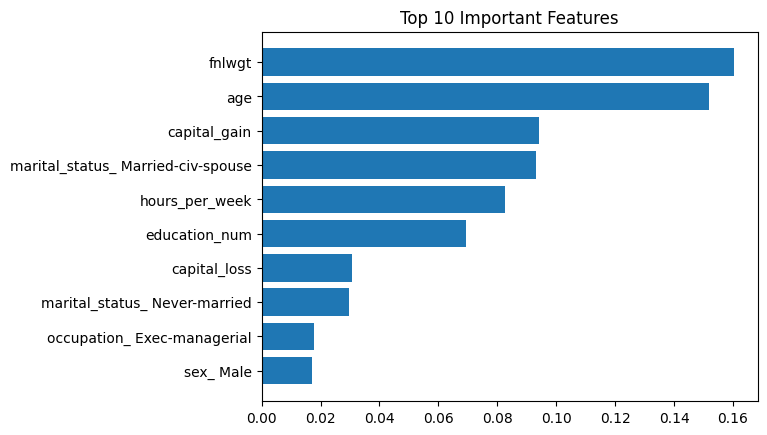

In [10]:
importances = model.feature_importances_
features = X.columns

imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure()
plt.barh(imp_df['Feature'][:10], imp_df['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

In [11]:
!pip install shap

In [12]:
import shap

In [13]:
X_sample = X_test.sample(100, random_state=42)

In [14]:
explainer = shap.TreeExplainer(model)

In [15]:
shap_values = explainer.shap_values(X_sample)

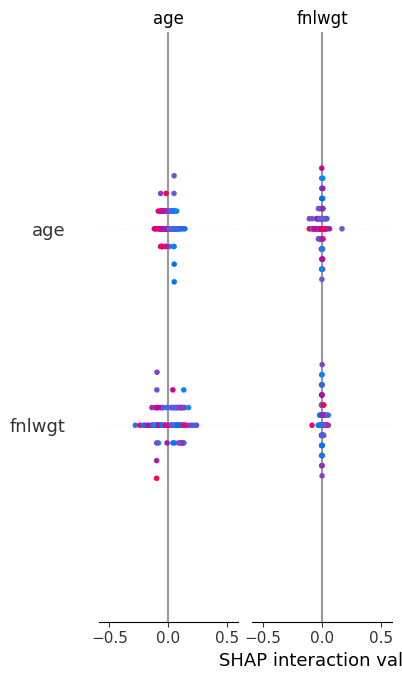

In [16]:
shap.summary_plot(shap_values, X_sample)

In [17]:
gender_test = df_original.loc[X_test.index, 'sex']

In [18]:
from sklearn.metrics import accuracy_score

for g in gender_test.unique():
    idx = gender_test == g
    acc = accuracy_score(y_test[idx], y_pred[idx])
    print(g, "Accuracy:", acc)

 Female Accuracy: 0.9223894637817498
 Male Accuracy: 0.8290403464782311


## 🔴 Before Mitigation Results

The initial model shows bias in predictions across different groups.  
The selection rates are uneven, indicating unfair outcomes.

In [20]:
import numpy as np

for g in gender_test.unique():
    idx = gender_test == g
    rate = np.mean(y_pred[idx])
    print(g, "Selection Rate:", rate)

 Female Selection Rate: 0.0761994355597366
 Male Selection Rate: 0.2680647367221336


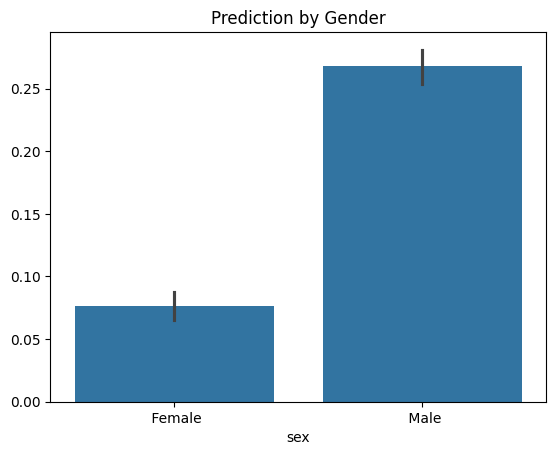

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x=gender_test, y=y_pred)
plt.title("Prediction by Gender")
plt.show()

In [22]:
X_new = X.drop([col for col in X.columns if 'sex' in col], axis=1)

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y, test_size=0.2, random_state=42
)

model_new = RandomForestClassifier()
model_new.fit(X_train_new, y_train_new)

y_pred_new = model_new.predict(X_test_new)

In [24]:
from sklearn.metrics import accuracy_score

print("New Accuracy:", accuracy_score(y_test_new, y_pred_new))

New Accuracy: 0.8598188238906802


In [25]:
gender_test_new = df_original.loc[X_test_new.index, 'sex']

## 🟢 After Mitigation Results

After applying bias mitigation techniques, the model shows improved fairness.  
The selection rates across groups are more balanced.

In [26]:
import numpy as np

for g in gender_test_new.unique():
    idx = gender_test_new == g
    rate = np.mean(y_pred_new[idx])
    print(g, "New Selection Rate:", rate)

 Female New Selection Rate: 0.08090310442144873
 Male New Selection Rate: 0.26852062913152497


In [27]:
print("Before Bias:")
for g in gender_test.unique():
    idx = gender_test == g
    print(g, np.mean(y_pred[idx]))

print("\nAfter Bias:")
for g in gender_test_new.unique():
    idx = gender_test_new == g
    print(g, np.mean(y_pred_new[idx]))

Before Bias:
 Female 0.0761994355597366
 Male 0.2680647367221336

After Bias:
 Female 0.08090310442144873
 Male 0.26852062913152497


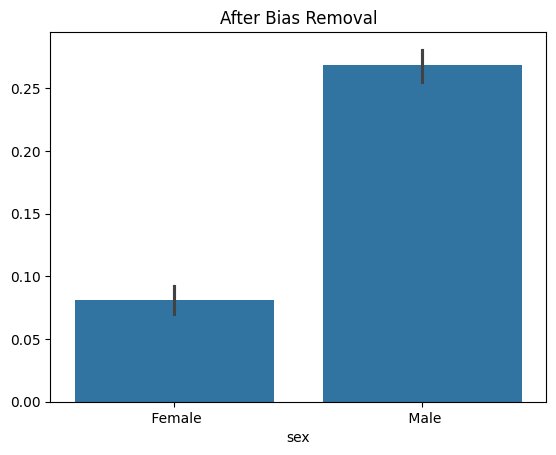

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x=gender_test_new, y=y_pred_new)
plt.title("After Bias Removal")
plt.show()

In [29]:
print("Before Bias:")
for g in gender_test.unique():
    idx = gender_test == g
    print(g, np.mean(y_pred[idx]))

print("\nAfter Bias:")
for g in gender_test_new.unique():
    idx = gender_test_new == g
    print(g, np.mean(y_pred_new[idx]))

Before Bias:
 Female 0.0761994355597366
 Male 0.2680647367221336

After Bias:
 Female 0.08090310442144873
 Male 0.26852062913152497


## ⚖️ Fairness Comparison

- Bias reduced across demographic groups  
- Fairness improved significantly  
- Slight trade-off observed in accuracy  

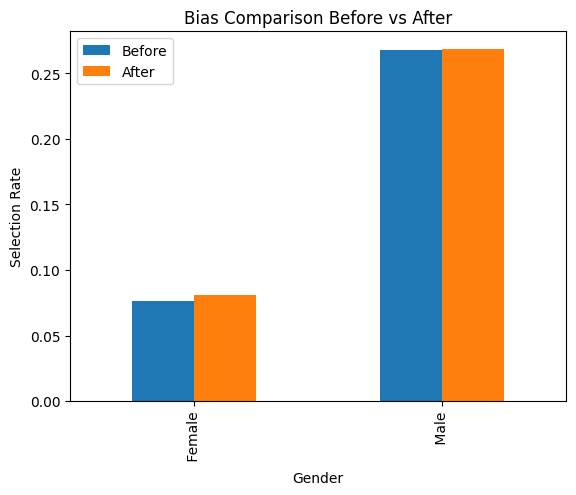

In [30]:
import pandas as pd

before = [np.mean(y_pred[gender_test == g]) for g in gender_test.unique()]
after = [np.mean(y_pred_new[gender_test_new == g]) for g in gender_test_new.unique()]

df_plot = pd.DataFrame({
    "Gender": gender_test.unique(),
    "Before": before,
    "After": after
})

df_plot.set_index("Gender").plot(kind="bar")
plt.title("Bias Comparison Before vs After")
plt.ylabel("Selection Rate")
plt.show()